In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)


def safe_filename(name: str) -> str:
    """Convert column names to safe filenames."""
    name = str(name)
    name = re.sub(r"[^\w\-]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name[:80]

In [2]:
#定位项目路径并创建EDA输出目录
CURRENT_DIR = Path.cwd().resolve()

PROJECT_DIR = None
for p in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (p / "data").exists() and ((p / "notebook").exists() or (p / "notebooks").exists() or (p / ".git").exists()):
        PROJECT_DIR = p
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Cannot locate project root. Please run this notebook inside the project folder."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
EDA_DIR = PROJECT_DIR / "reports" / "eda"
TABLE_DIR = EDA_DIR / "tables"
FIG_DIR = EDA_DIR / "figures"

NUMERIC_FIG_DIR = FIG_DIR / "numeric_distributions"
CATEGORICAL_FIG_DIR = FIG_DIR / "categorical_distributions"
NUMERIC_TARGET_FIG_DIR = FIG_DIR / "numeric_by_target"
CATEGORICAL_TARGET_FIG_DIR = FIG_DIR / "categorical_by_target"

for d in [
    EDA_DIR,
    TABLE_DIR,
    FIG_DIR,
    NUMERIC_FIG_DIR,
    CATEGORICAL_FIG_DIR,
    NUMERIC_TARGET_FIG_DIR,
    CATEGORICAL_TARGET_FIG_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("EDA_DIR:", EDA_DIR)

PROJECT_DIR: D:\A_projects\kaggle-customer-churn-prediction
RAW_DIR: D:\A_projects\kaggle-customer-churn-prediction\data\raw
EDA_DIR: D:\A_projects\kaggle-customer-churn-prediction\reports\eda


In [3]:
#读取数据
train_path = RAW_DIR / "train.csv"
test_path = RAW_DIR / "test.csv"
sample_submission_path = RAW_DIR / "sample_submission.csv"

missing_files = [p.name for p in [train_path, test_path, sample_submission_path] if not p.exists()]
if missing_files:
    print("Files currently in data/raw:")
    for p in RAW_DIR.glob("*"):
        print(" -", p.name)
    raise FileNotFoundError(f"Missing files in data/raw: {missing_files}")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

TARGET = "Churn"

if TARGET not in train.columns:
    raise ValueError(f"Target column `{TARGET}` not found in train.csv. Current columns: {train.columns.tolist()}")

ID_COLS = [
    c for c in train.columns
    if c.lower() in ["id", "customerid", "customer_id", "clientid", "client_id"]
]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)
print("Target:", TARGET)
print("ID columns:", ID_COLS)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (594194, 21)
Test shape: (254655, 20)
Sample submission shape: (254655, 2)
Target: Churn
ID columns: ['id']


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [4]:
#数据字段总览
def build_overview(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in df.columns:
        non_null_values = df[col].dropna().unique()[:5]
        sample_values = ", ".join(map(str, non_null_values))

        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "n_missing": int(df[col].isna().sum()),
            "missing_rate": float(df[col].isna().mean()),
            "n_unique": int(df[col].nunique(dropna=True)),
            "sample_values": sample_values
        })

    return pd.DataFrame(rows)


train_overview = build_overview(train)
test_overview = build_overview(test)

train_overview.to_csv(TABLE_DIR / "train_overview.csv", index=False, encoding="utf-8-sig")
test_overview.to_csv(TABLE_DIR / "test_overview.csv", index=False, encoding="utf-8-sig")

display(train_overview)
display(test_overview)

,column,dtype,n_missing,missing_rate,n_unique,sample_values
0,id,int64,0,0.0,594194,"0, 1, 2, 3, 4"
1,gender,str,0,0.0,2,"Male, Female"
2,SeniorCitizen,int64,0,0.0,2,"0, 1"
3,Partner,str,0,0.0,2,"Yes, No"
4,Dependents,str,0,0.0,2,"Yes, No"
5,tenure,int64,0,0.0,72,"29, 58, 1, 24, 72"
6,PhoneService,str,0,0.0,2,"Yes, No"
7,MultipleLines,str,0,0.0,3,"No, Yes, No phone service"
8,InternetService,str,0,0.0,3,"DSL, Fiber optic, No"
9,OnlineSecurity,str,0,0.0,3,"Yes, No, No internet service"


,column,dtype,n_missing,missing_rate,n_unique,sample_values
0,id,int64,0,0.0,254655,"594194, 594195, 594196, 594197, 594198"
1,gender,str,0,0.0,2,"Female, Male"
2,SeniorCitizen,int64,0,0.0,2,"0, 1"
3,Partner,str,0,0.0,2,"Yes, No"
4,Dependents,str,0,0.0,2,"No, Yes"
5,tenure,int64,0,0.0,72,"72, 71, 12, 15, 24"
6,PhoneService,str,0,0.0,2,"Yes, No"
7,MultipleLines,str,0,0.0,3,"Yes, No, No phone service"
8,InternetService,str,0,0.0,3,"Fiber optic, No, DSL"
9,OnlineSecurity,str,0,0.0,3,"Yes, No internet service, No"


In [5]:
#划分字段类型
feature_cols = [c for c in train.columns if c != TARGET]

numeric_cols = train[feature_cols].select_dtypes(include=["number", "bool"]).columns.tolist()
raw_categorical_cols = train[feature_cols].select_dtypes(exclude=["number", "bool"]).columns.tolist()

low_card_num_cols = [
    c for c in numeric_cols
    if c not in ID_COLS and train[c].nunique(dropna=True) <= 20
]

continuous_cols = [
    c for c in numeric_cols
    if c not in ID_COLS and c not in low_card_num_cols
]

categorical_like_cols = raw_categorical_cols + low_card_num_cols

feature_summary = pd.DataFrame({
    "feature_type": [
        "id_cols",
        "continuous_numeric_cols",
        "categorical_like_cols",
        "raw_categorical_cols",
        "low_card_numeric_cols"
    ],
    "n_features": [
        len(ID_COLS),
        len(continuous_cols),
        len(categorical_like_cols),
        len(raw_categorical_cols),
        len(low_card_num_cols)
    ],
    "features": [
        ", ".join(ID_COLS),
        ", ".join(continuous_cols),
        ", ".join(categorical_like_cols),
        ", ".join(raw_categorical_cols),
        ", ".join(low_card_num_cols)
    ]
})

feature_summary.to_csv(TABLE_DIR / "feature_summary.csv", index=False, encoding="utf-8-sig")

display(feature_summary)

,feature_type,n_features,features
0,id_cols,1,id
1,continuous_numeric_cols,3,"tenure, MonthlyCharges, TotalCharges"
2,categorical_like_cols,16,"gender, Partner, Dependents, PhoneService, Mul..."
3,raw_categorical_cols,15,"gender, Partner, Dependents, PhoneService, Mul..."
4,low_card_numeric_cols,1,SeniorCitizen


In [6]:
#缺失值和重复值检查
missing_summary = pd.DataFrame({
    "column": train.columns,
    "train_missing_count": train.isna().sum().values,
    "train_missing_rate": train.isna().mean().values,
    "test_missing_count": [
        test[c].isna().sum() if c in test.columns else np.nan
        for c in train.columns
    ],
    "test_missing_rate": [
        test[c].isna().mean() if c in test.columns else np.nan
        for c in train.columns
    ],
})

missing_summary = missing_summary.sort_values(
    ["train_missing_rate", "test_missing_rate"],
    ascending=False
)

missing_summary.to_csv(TABLE_DIR / "missing_summary.csv", index=False, encoding="utf-8-sig")

duplicate_summary = pd.DataFrame({
    "item": [
        "train_duplicated_rows",
        "test_duplicated_rows"
    ],
    "count": [
        int(train.duplicated().sum()),
        int(test.duplicated().sum())
    ]
})

if ID_COLS:
    for id_col in ID_COLS:
        duplicate_summary = pd.concat([
            duplicate_summary,
            pd.DataFrame({
                "item": [
                    f"train_duplicated_{id_col}",
                    f"test_duplicated_{id_col}"
                ],
                "count": [
                    int(train[id_col].duplicated().sum()),
                    int(test[id_col].duplicated().sum())
                ]
            })
        ], ignore_index=True)

duplicate_summary.to_csv(TABLE_DIR / "duplicate_summary.csv", index=False, encoding="utf-8-sig")

display(missing_summary)
display(duplicate_summary)

,column,train_missing_count,train_missing_rate,test_missing_count,test_missing_rate
0,id,0,0.0,0.0,0.0
1,gender,0,0.0,0.0,0.0
2,SeniorCitizen,0,0.0,0.0,0.0
3,Partner,0,0.0,0.0,0.0
4,Dependents,0,0.0,0.0,0.0
5,tenure,0,0.0,0.0,0.0
6,PhoneService,0,0.0,0.0,0.0
7,MultipleLines,0,0.0,0.0,0.0
8,InternetService,0,0.0,0.0,0.0
9,OnlineSecurity,0,0.0,0.0,0.0


,item,count
0,train_duplicated_rows,0
1,test_duplicated_rows,0
2,train_duplicated_id,0
3,test_duplicated_id,0


,count,ratio
Churn,,
No,460377,0.774792
Yes,133817,0.225208


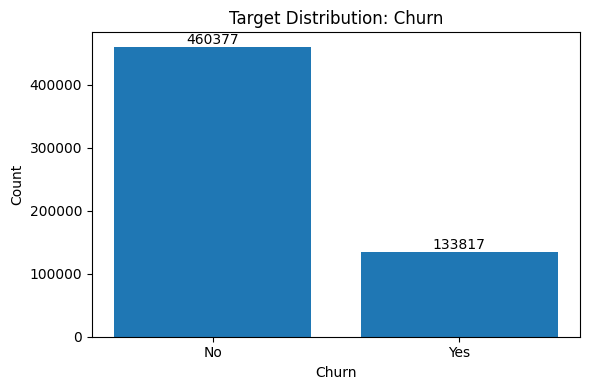

In [7]:
#目标变量Churn分布
def to_binary_numeric(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    mapper = {
        "yes": 1, "y": 1, "true": 1, "t": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "f": 0, "0": 0
    }

    return s.astype(str).str.strip().str.lower().map(mapper)


target_numeric = to_binary_numeric(train[TARGET])
train["_target_numeric_eda"] = target_numeric

target_dist = train[TARGET].value_counts(dropna=False).rename("count").to_frame()
target_dist["ratio"] = target_dist["count"] / len(train)

target_dist.to_csv(TABLE_DIR / "target_distribution.csv", encoding="utf-8-sig")

display(target_dist)

fig, ax = plt.subplots(figsize=(6, 4))
x_labels = target_dist.index.astype(str)
ax.bar(x_labels, target_dist["count"])
ax.set_title("Target Distribution: Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")

for i, value in enumerate(target_dist["count"]):
    ax.text(i, value, str(value), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(FIG_DIR / "target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
#数值变量描述统计
if continuous_cols:
    numeric_describe = train[continuous_cols].describe().T
    numeric_describe["missing_rate"] = train[continuous_cols].isna().mean()
    numeric_describe["skew"] = train[continuous_cols].skew(numeric_only=True)
    numeric_describe["kurtosis"] = train[continuous_cols].kurtosis(numeric_only=True)

    numeric_describe.to_csv(TABLE_DIR / "numeric_describe.csv", encoding="utf-8-sig")
    display(numeric_describe)
else:
    print("No continuous numeric columns found.")

#数值变量分布图
MAX_PLOT_COLS = 40

for col in continuous_cols[:MAX_PLOT_COLS]:
    data = train[col].dropna()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(data, bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

    fig.tight_layout()
    fig.savefig(NUMERIC_FIG_DIR / f"distribution_{safe_filename(col)}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"Saved numeric distribution figures to: {NUMERIC_FIG_DIR}")

#类别变量分布图
categorical_count_rows = []

for col in categorical_like_cols:
    vc = train[col].astype("object").fillna("__MISSING__").value_counts(dropna=False)

    for level, count in vc.items():
        categorical_count_rows.append({
            "column": col,
            "level": level,
            "count": int(count),
            "ratio": float(count / len(train))
        })

    plot_data = vc.head(20).sort_values()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(plot_data.index.astype(str), plot_data.values)
    ax.set_title(f"Top Categories of {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)

    fig.tight_layout()
    fig.savefig(CATEGORICAL_FIG_DIR / f"count_{safe_filename(col)}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

categorical_count_summary = pd.DataFrame(categorical_count_rows)
categorical_count_summary.to_csv(TABLE_DIR / "categorical_count_summary.csv", index=False, encoding="utf-8-sig")

display(categorical_count_summary.head(50))
print(f"Saved categorical distribution figures to: {CATEGORICAL_FIG_DIR}")

,count,mean,std,min,25%,50%,75%,max,missing_rate,skew,kurtosis
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00,0.0,0.063050,-1.487182
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75,0.0,-0.289486,-1.277955
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80,0.0,0.909169,-0.446287


Saved numeric distribution figures to: D:\A_projects\kaggle-customer-churn-prediction\reports\eda\figures\numeric_distributions


,column,level,count,ratio
0,gender,Female,298738,0.502762
1,gender,Male,295456,0.497238
2,Partner,Yes,309554,0.520965
3,Partner,No,284640,0.479035
4,Dependents,No,414362,0.697351
5,Dependents,Yes,179832,0.302649
6,PhoneService,Yes,557893,0.938907
7,PhoneService,No,36301,0.061093
8,MultipleLines,No,283384,0.476922
9,MultipleLines,Yes,274509,0.461985


Saved categorical distribution figures to: D:\A_projects\kaggle-customer-churn-prediction\reports\eda\figures\categorical_distributions


In [9]:
#数值变量与Churn的关系
is_binary_target = target_numeric.nunique(dropna=True) == 2

if is_binary_target and continuous_cols:
    numeric_target_rows = []

    for col in continuous_cols:
        temp = train[[col, "_target_numeric_eda"]].dropna()

        grouped = temp.groupby("_target_numeric_eda")[col].agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max"
        ).reset_index()

        grouped.insert(0, "column", col)
        numeric_target_rows.append(grouped)

        if col in continuous_cols[:MAX_PLOT_COLS]:
            classes = sorted(temp["_target_numeric_eda"].unique())
            data_by_class = [
                temp.loc[temp["_target_numeric_eda"] == cls, col]
                for cls in classes
            ]

            fig, ax = plt.subplots(figsize=(6, 4))
            ax.boxplot(data_by_class, labels=[str(int(cls)) for cls in classes], showfliers=False)
            ax.set_title(f"{col} by Churn")
            ax.set_xlabel("Churn")
            ax.set_ylabel(col)

            fig.tight_layout()
            fig.savefig(NUMERIC_TARGET_FIG_DIR / f"boxplot_{safe_filename(col)}_by_churn.png", dpi=200, bbox_inches="tight")
            plt.close(fig)

    numeric_target_summary = pd.concat(numeric_target_rows, ignore_index=True)
    numeric_target_summary.to_csv(TABLE_DIR / "numeric_by_target_summary.csv", index=False, encoding="utf-8-sig")

    display(numeric_target_summary.head(50))
    print(f"Saved numeric-by-target figures to: {NUMERIC_TARGET_FIG_DIR}")
else:
    print("Target is not binary numeric or no continuous numeric columns found. Skipped numeric-by-target analysis.")

C:\Users\pcx\AppData\Local\Temp\ipykernel_33436\3150773860.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=[str(int(cls)) for cls in classes], showfliers=False)
C:\Users\pcx\AppData\Local\Temp\ipykernel_33436\3150773860.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=[str(int(cls)) for cls in classes], showfliers=False)
C:\Users\pcx\AppData\Local\Temp\ipykernel_33436\3150773860.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=[str(int(cls)) for cls in classes], showfliers=False)


,column,_target_numeric_eda,count,mean,median,std,min,max
0,tenure,0,460377,42.231313,46.00,23.987158,1.00,72.00
1,tenure,1,133817,17.125343,10.00,17.919396,1.00,72.00
2,MonthlyCharges,0,460377,61.293633,65.40,32.287427,18.25,118.75
3,MonthlyCharges,1,133817,81.597525,85.05,19.490306,18.80,118.75
4,TotalCharges,0,460377,2771.500515,1688.75,2423.054655,18.80,8684.80
5,TotalCharges,1,133817,1540.976020,829.55,1797.643905,18.80,8684.80


Saved numeric-by-target figures to: D:\A_projects\kaggle-customer-churn-prediction\reports\eda\figures\numeric_by_target


In [10]:
#类别变量与Churn的关系
if is_binary_target and categorical_like_cols:
    categorical_target_rows = []

    for col in categorical_like_cols:
        temp = train[[col, "_target_numeric_eda"]].copy()
        temp[col] = temp[col].astype("object").fillna("__MISSING__")

        summary = temp.groupby(col)["_target_numeric_eda"].agg(
            count="count",
            churn_rate="mean"
        ).reset_index()

        summary.insert(0, "column", col)
        summary = summary.sort_values(["column", "count"], ascending=[True, False])

        categorical_target_rows.append(summary)

        plot_data = summary.sort_values("count", ascending=False).head(20)
        plot_data = plot_data.sort_values("churn_rate")

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.barh(plot_data[col].astype(str), plot_data["churn_rate"])
        ax.set_title(f"Churn Rate by {col}")
        ax.set_xlabel("Churn Rate")
        ax.set_ylabel(col)

        fig.tight_layout()
        fig.savefig(CATEGORICAL_TARGET_FIG_DIR / f"churn_rate_{safe_filename(col)}.png", dpi=200, bbox_inches="tight")
        plt.close(fig)

    categorical_target_summary = pd.concat(categorical_target_rows, ignore_index=True)
    categorical_target_summary.to_csv(TABLE_DIR / "categorical_by_target_summary.csv", index=False, encoding="utf-8-sig")

    display(categorical_target_summary.head(80))
    print(f"Saved categorical-by-target figures to: {CATEGORICAL_TARGET_FIG_DIR}")
else:
    print("Target is not binary numeric or no categorical-like columns found. Skipped categorical-by-target analysis.")

,column,gender,count,churn_rate,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen
0,gender,Female,298738,0.228036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gender,Male,295456,0.222348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Partner,NaN,309554,0.133796,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Partner,NaN,284640,0.324621,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dependents,NaN,414362,0.291354,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Dependents,NaN,179832,0.072796,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PhoneService,NaN,557893,0.228920,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,PhoneService,NaN,36301,0.168150,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MultipleLines,NaN,283384,0.182322,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,MultipleLines,NaN,274509,0.277026,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved categorical-by-target figures to: D:\A_projects\kaggle-customer-churn-prediction\reports\eda\figures\categorical_by_target


,correlation_with_churn,abs_correlation_with_churn
tenure,-0.418453,0.418453
MonthlyCharges,0.272997,0.272997
TotalCharges,-0.218365,0.218365


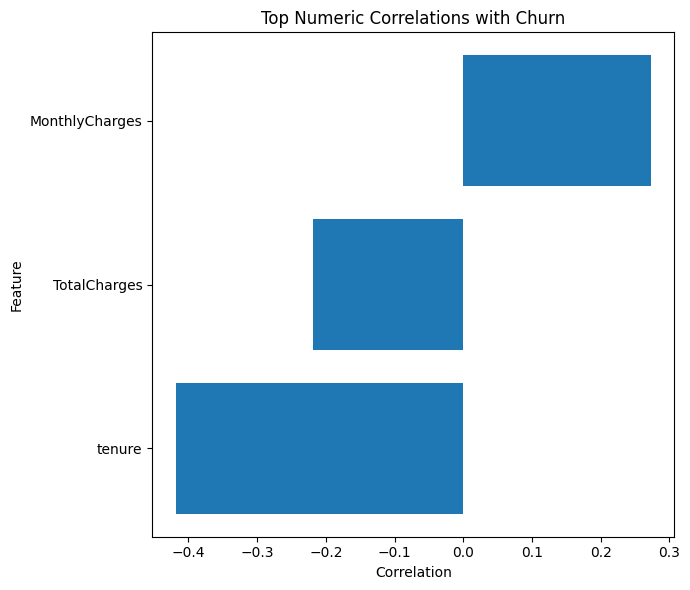

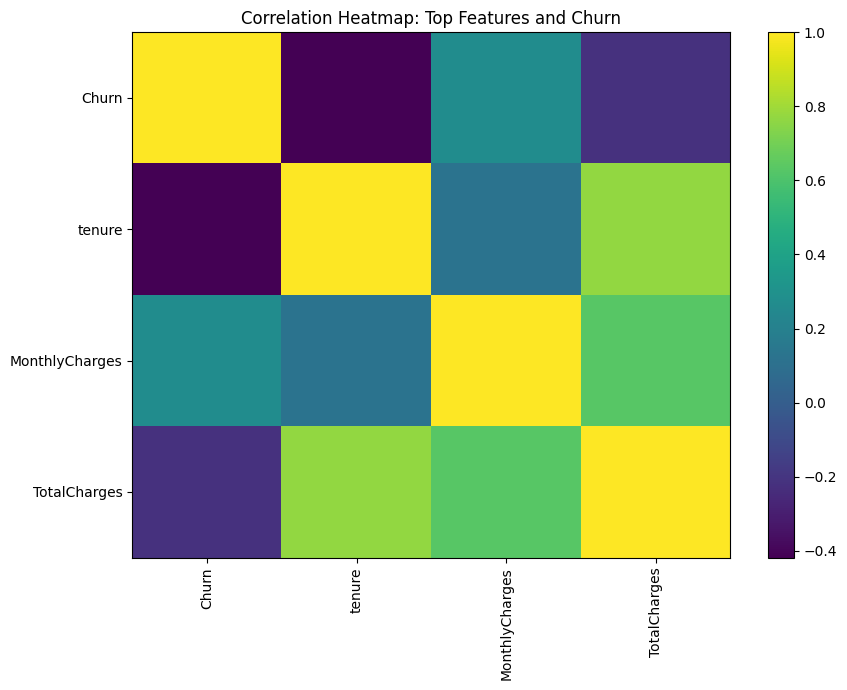

In [11]:
#相关性分析
if is_binary_target and continuous_cols:
    corr_data = train[continuous_cols].copy()
    corr_data[TARGET] = target_numeric

    corr_matrix = corr_data.corr(numeric_only=True)
    corr_matrix.to_csv(TABLE_DIR / "correlation_matrix.csv", encoding="utf-8-sig")

    target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(
        key=lambda s: s.abs(),
        ascending=False
    )

    target_corr_df = target_corr.rename("correlation_with_churn").to_frame()
    target_corr_df["abs_correlation_with_churn"] = target_corr_df["correlation_with_churn"].abs()
    target_corr_df.to_csv(TABLE_DIR / "target_correlation.csv", encoding="utf-8-sig")

    display(target_corr_df)

    top_corr = target_corr.head(20).sort_values()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top_corr.index, top_corr.values)
    ax.set_title("Top Numeric Correlations with Churn")
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Feature")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_correlation_top20.png", dpi=200, bbox_inches="tight")
    plt.show()

    selected_cols = [TARGET] + target_corr.abs().head(min(20, len(target_corr))).index.tolist()
    heatmap_data = corr_matrix.loc[selected_cols, selected_cols]

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(heatmap_data.values, aspect="auto")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(selected_cols)))
    ax.set_yticks(np.arange(len(selected_cols)))
    ax.set_xticklabels(selected_cols, rotation=90)
    ax.set_yticklabels(selected_cols)
    ax.set_title("Correlation Heatmap: Top Features and Churn")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "correlation_heatmap_top_features.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Target is not binary numeric or no continuous numeric columns found. Skipped correlation analysis.")

In [12]:
#训练集与测试集分布差异检查
numeric_shift_rows = []

for col in numeric_cols:
    if col in ID_COLS:
        continue

    if col not in test.columns:
        continue

    train_mean = train[col].mean()
    test_mean = test[col].mean()
    train_std = train[col].std()
    test_std = test[col].std()

    numeric_shift_rows.append({
        "column": col,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "mean_diff": test_mean - train_mean,
        "train_std": train_std,
        "test_std": test_std,
        "std_ratio_test_over_train": test_std / train_std if train_std != 0 else np.nan,
        "train_missing_rate": train[col].isna().mean(),
        "test_missing_rate": test[col].isna().mean(),
        "train_n_unique": train[col].nunique(dropna=True),
        "test_n_unique": test[col].nunique(dropna=True)
    })

numeric_shift_summary = pd.DataFrame(numeric_shift_rows)

if not numeric_shift_summary.empty:
    numeric_shift_summary["abs_mean_diff"] = numeric_shift_summary["mean_diff"].abs()
    numeric_shift_summary = numeric_shift_summary.sort_values("abs_mean_diff", ascending=False)
    numeric_shift_summary.to_csv(TABLE_DIR / "numeric_train_test_shift.csv", index=False, encoding="utf-8-sig")
    display(numeric_shift_summary)
else:
    print("No numeric columns available for train-test shift analysis.")


categorical_shift_rows = []

for col in categorical_like_cols:
    if col not in test.columns:
        continue

    train_levels = set(train[col].astype("object").dropna().unique())
    test_levels = set(test[col].astype("object").dropna().unique())

    categorical_shift_rows.append({
        "column": col,
        "train_n_levels": len(train_levels),
        "test_n_levels": len(test_levels),
        "n_new_levels_in_test": len(test_levels - train_levels),
        "new_levels_in_test": ", ".join(map(str, list(test_levels - train_levels)[:20])),
        "n_missing_levels_in_test": len(train_levels - test_levels),
        "missing_levels_in_test": ", ".join(map(str, list(train_levels - test_levels)[:20])),
    })

categorical_shift_summary = pd.DataFrame(categorical_shift_rows)

if not categorical_shift_summary.empty:
    categorical_shift_summary = categorical_shift_summary.sort_values(
        "n_new_levels_in_test",
        ascending=False
    )
    categorical_shift_summary.to_csv(TABLE_DIR / "categorical_train_test_shift.csv", index=False, encoding="utf-8-sig")
    display(categorical_shift_summary)
else:
    print("No categorical-like columns available for train-test shift analysis.")

,column,train_mean,test_mean,mean_diff,train_std,test_std,std_ratio_test_over_train,train_missing_rate,test_missing_rate,train_n_unique,test_n_unique,abs_mean_diff
3,TotalCharges,2494.377057,2544.617351,50.240295,2353.916710,2348.124379,0.997539,0.0,0.0,31910,24995,50.240295
1,tenure,36.577258,37.279716,0.702458,25.061922,24.777625,0.988656,0.0,0.0,72,72,0.702458
2,MonthlyCharges,65.866223,66.130803,0.264580,31.067444,31.104139,1.001181,0.0,0.0,1921,1875,0.264580
0,SeniorCitizen,0.114102,0.113620,-0.000482,0.317936,0.317350,0.998158,0.0,0.0,2,2,0.000482


,column,train_n_levels,test_n_levels,n_new_levels_in_test,new_levels_in_test,n_missing_levels_in_test,missing_levels_in_test
0,gender,2,2,0,,0,
1,Partner,2,2,0,,0,
2,Dependents,2,2,0,,0,
3,PhoneService,2,2,0,,0,
4,MultipleLines,3,3,0,,0,
5,InternetService,3,3,0,,0,
6,OnlineSecurity,3,3,0,,0,
7,OnlineBackup,3,3,0,,0,
8,DeviceProtection,3,3,0,,0,
9,TechSupport,3,3,0,,0,


In [13]:
#生成EDA报告
def pct(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2%}"


train_rows, train_cols = train.shape
test_rows, test_cols = test.shape

target_text = []
for idx, row in target_dist.iterrows():
    target_text.append(f"{idx}: {int(row['count'])}({row['ratio']:.2%})")
target_text = "; ".join(target_text)

missing_nonzero = missing_summary[
    (missing_summary["train_missing_rate"] > 0) |
    (missing_summary["test_missing_rate"] > 0)
]

if missing_nonzero.empty:
    missing_text = "训练集与测试集均未发现缺失值。"
else:
    top_missing = missing_nonzero.head(10)
    missing_text = "存在缺失值，缺失率较高的字段包括：" + "、".join(top_missing["column"].astype(str).tolist())

if is_binary_target and continuous_cols:
    top_corr_text = "、".join(
        [
            f"{idx}({val:.4f})"
            for idx, val in target_corr.head(10).items()
        ]
    )
else:
    top_corr_text = "未生成相关性结果。"

report = f"""# Predict Customer Churn EDA Report

## 1. 数据概况

本项目为客户流失二分类预测任务，训练集目标变量为`{TARGET}`。当前EDA阶段仅分析数据结构、变量分布、目标变量分布以及训练集与测试集的一致性，不在本阶段提前确定最终模型。

训练集规模为{train_rows}行、{train_cols}列；测试集规模为{test_rows}行、{test_cols}列。识别到的ID字段为：{", ".join(ID_COLS) if ID_COLS else "无"}。

## 2. 目标变量分布

目标变量`{TARGET}`的分布为：{target_text}。

![target_distribution](figures/target_distribution.png)

该结果用于判断客户流失样本是否存在类别不平衡。如果正负样本比例差异较大，后续模型评估不能只看Accuracy，还需要同时关注AUC、F1、Recall、Precision等指标。

## 3. 字段类型

连续数值变量数量为{len(continuous_cols)}，类别型或低基数变量数量为{len(categorical_like_cols)}。字段类型划分结果已保存至`tables/feature_summary.csv`。

## 4. 缺失值与重复值检查

{missing_text}

重复值检查结果已保存至`tables/duplicate_summary.csv`。如果ID字段存在重复，需要进一步判断是否为真实重复客户记录或数据构造方式导致的重复编号。

## 5. 单变量分布

数值变量分布图已保存至`figures/numeric_distributions/`，类别变量分布图已保存至`figures/categorical_distributions/`。该部分主要用于识别偏态分布、异常值、长尾类别以及低频类别。

## 6. 变量与Churn的关系

数值变量与`Churn`的分组统计已保存至`tables/numeric_by_target_summary.csv`，箱线图已保存至`figures/numeric_by_target/`。

类别变量与`Churn`的流失率统计已保存至`tables/categorical_by_target_summary.csv`，流失率图已保存至`figures/categorical_by_target/`。

## 7. 相关性分析

与`Churn`相关性较高的数值变量包括：{top_corr_text}。

相关性矩阵已保存至`tables/correlation_matrix.csv`，目标变量相关性排序已保存至`tables/target_correlation.csv`。

![target_correlation_top20](figures/target_correlation_top20.png)

![correlation_heatmap_top_features](figures/correlation_heatmap_top_features.png)

需要注意，相关性只能反映线性关系，不能直接说明因果关系。若某些变量与`Churn`相关性较低，也不代表其在非线性模型中完全无效。

## 8. 训练集与测试集分布差异

数值变量的训练集-测试集分布差异已保存至`tables/numeric_train_test_shift.csv`，类别变量的新水平与缺失水平检查已保存至`tables/categorical_train_test_shift.csv`。

如果测试集中出现训练集中没有的新类别，后续建模阶段需要使用能够处理未知类别的编码方式，避免提交阶段报错。

## 9. EDA阶段结论

本阶段完成了数据质量、目标变量分布、字段类型、单变量分布、双变量关系、相关性以及训练集-测试集一致性检查。后续建模阶段应以EDA结果为依据，重点关注以下问题：

1. 是否存在类别不平衡；
2. 是否存在缺失值或异常值；
3. 类别变量是否需要编码；
4. 数值变量是否存在明显偏态或极端值；
5. 训练集和测试集是否存在明显分布差异；
6. 模型评价指标不应只依赖Accuracy，应结合AUC、F1、Recall和Precision综合判断。
"""

report_path = EDA_DIR / "eda_report.md"
report_path.write_text(report, encoding="utf-8")

print(f"EDA report saved to: {report_path}")

EDA report saved to: D:\A_projects\kaggle-customer-churn-prediction\reports\eda\eda_report.md
